# Stage 1 — M5 Ingestion and Preprocessing

## Objective

Convert raw M5 retail data into the weekly regional SKU panel required by
the supply-chain forecasting and optimization engine.

### Output contract

One row represents:

`(week, sku_id)`

The processed panel contains:

- regional weekly demand;
- product hierarchy metadata;
- calendar and event information;
- SNAP information;
- regional price information.

A maximum of 20 SKUs is retained for the first application version.

## Business interpretation

The original M5 dataset represents Walmart item-store daily sales.

For this project, stores within one state are treated as customer locations
supplied by one manufacturing region. Store-level sales are therefore
aggregated into regional SKU demand before forecasting.

In [6]:
from pathlib import Path

from new_demfor_planopti.data.m5 import M5Config


# ============================================================
# PROJECT PATH SETUP
# ============================================================

# VS Code may execute a notebook either from:
#   project_root/
# or
#   project_root/notebooks/
#
# Find the project root by looking for pyproject.toml.

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root containing pyproject.toml"
    )


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


CONFIG = M5Config(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,

    target_state="CA",
    max_skus=20,

    selection_history_fraction=0.80,
    min_active_week_fraction=0.20,
)


# ============================================================
# VERIFY PATHS
# ============================================================

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nRaw directory:")
print(CONFIG.raw_dir)

print("\nExpected files:")
print("sales:   ", CONFIG.sales_path)
print("calendar:", CONFIG.calendar_path)
print("prices:  ", CONFIG.prices_path)

print("\nExistence:")
print("sales:   ", CONFIG.sales_path.exists())
print("calendar:", CONFIG.calendar_path.exists())
print("prices:  ", CONFIG.prices_path.exists())

Current working directory:
t:\Tanmay@IITK\Projects\new_demfor_planopti\notebooks

Project root:
T:\Tanmay@IITK\Projects\new_demfor_planopti

Raw directory:
T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw

Expected files:
sales:    T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\sales_train_evaluation.csv
calendar: T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\calendar.csv
prices:   T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\sell_prices.csv

Existence:
sales:    True
calendar: True
prices:   True


## 1. Inspect raw M5 sources

Three M5 tables are required:

1. `sales_train_evaluation.csv`
   - daily unit sales;
   - stored in wide format;
   - one row represents an item-store series.

2. `calendar.csv`
   - maps M5 day identifiers (`d_1`, `d_2`, ...) to real dates;
   - contains Walmart week identifiers;
   - contains SNAP and event information.

3. `sell_prices.csv`
   - weekly item-store prices;
   - key: `(store_id, item_id, wm_yr_wk)`.

Understanding these keys before joining the data is critical because sales,
calendar and price tables operate at different granularities.

In [8]:
inspection = inspect_raw_files(CONFIG)

inspection

sales, calendar, prices = load_m5_raw(CONFIG)

print("sales shape:   ", sales.shape)
print("calendar shape:", calendar.shape)
print("prices shape:  ", prices.shape)

Loading sales...
Loading calendar...
Loading prices...
sales shape:    (30490, 1947)
calendar shape: (1969, 14)
prices shape:   (6841121, 4)


## 2. Validate M5 keys

The important key relationships are:

### Sales

`id`

uniquely identifies an item-store sales series.

### Calendar

`d`

maps a sales column such as `d_100` to its actual calendar date and
`wm_yr_wk`.

### Price

The price table must be unique on:

`(store_id, item_id, wm_yr_wk)`

These assumptions are validated before any transformation or aggregation
is performed.

In [9]:
validate_raw_schema(
    sales,
    calendar,
    prices,
)

print("Raw schemas and keys validated.")

Raw schemas and keys validated.


In [10]:
print("sales['id'] unique:", sales["id"].is_unique)
print("calendar['d'] unique:", calendar["d"].is_unique)

print(
    "price duplicate keys:",
    prices.duplicated(
        ["store_id", "item_id", "wm_yr_wk"]
    ).sum(),
)

sales['id'] unique: True
calendar['d'] unique: True
price duplicate keys: 0


In [11]:
calendar.loc[
    calendar["d"].isin(["d_1", "d_2", "d_3"]),
    [
        "d",
        "date",
        "wm_yr_wk",
        "weekday",
        "event_name_1",
        "event_type_1",
        "snap_CA",
    ],
]

,d,date,wm_yr_wk,weekday,event_name_1,event_type_1,snap_CA
0,d_1,2011-01-29,11101,Saturday,NaN,NaN,0
1,d_2,2011-01-30,11101,Sunday,NaN,NaN,0
2,d_3,2011-01-31,11101,Monday,NaN,NaN,0


## 3. Aggregate geography

The M5 forecasting competition predicts individual item-store series.

That granularity is not appropriate for our manufacturing optimization
problem.

We assume one plant supplies a regional market. California is selected as
the initial region and all California store demand will ultimately be
aggregated to the SKU level.

This transforms the business interpretation from:

`item × store × day`

to:

`SKU × region × week`.

In [12]:
sales["state_id"].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [13]:
regional_sales = filter_geography(
    sales,
    CONFIG.target_state,
)

print(
    "regional rows:",
    regional_sales.shape,
)

print(
    "stores:",
    regional_sales["store_id"].nunique(),
)

print(
    "unique items:",
    regional_sales["item_id"].nunique(),
)

regional_sales["store_id"].value_counts()

regional rows: (12196, 1947)
stores: 4
unique items: 3049


store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
Name: count, dtype: int64

## 4. Select the initial SKU portfolio

The first application version is deliberately limited to at most 20 SKUs.

Instead of selecting SKUs using the complete history, only the first 80%
of observations are used to rank products. This avoids choosing the
portfolio using information from the final period that will eventually
be used for model validation.

The ranking criterion is total regional unit demand.

A minimum activity threshold is also applied so the initial demonstration
does not consist entirely of extremely sparse products.

In [14]:
sku_manifest = select_skus(
    regional_sales=regional_sales,
    calendar=calendar,
    config=CONFIG,
)

sku_manifest

,selection_rank,sku_id,cat_id,dept_id,selection_demand,active_week_fraction,selection_weeks,stores
0,1,FOODS_3_090,FOODS,FOODS_3,410776,0.860360,222,4
1,2,FOODS_3_586,FOODS,FOODS_3,257532,1.000000,222,4
2,3,FOODS_3_252,FOODS,FOODS_3,188633,1.000000,222,4
3,4,FOODS_3_808,FOODS,FOODS_3,148441,0.981982,222,4
4,5,FOODS_3_635,FOODS,FOODS_3,143238,0.986486,222,4
5,6,FOODS_3_541,FOODS,FOODS_3,141163,0.986486,222,4
6,7,FOODS_3_587,FOODS,FOODS_3,133185,1.000000,222,4
7,8,FOODS_3_120,FOODS,FOODS_3,122253,0.729730,222,4
8,9,FOODS_3_714,FOODS,FOODS_3,115541,1.000000,222,4
9,10,FOODS_3_555,FOODS,FOODS_3,114072,1.000000,222,4


In [16]:
selected_skus = sku_manifest["sku_id"].tolist()

selected_skus

['FOODS_3_090',
 'FOODS_3_586',
 'FOODS_3_252',
 'FOODS_3_808',
 'FOODS_3_635',
 'FOODS_3_541',
 'FOODS_3_587',
 'FOODS_3_120',
 'FOODS_3_714',
 'FOODS_3_555',
 'FOODS_3_080',
 'FOODS_3_319',
 'FOODS_3_202',
 'FOODS_3_318',
 'FOODS_2_197',
 'FOODS_3_681',
 'FOODS_3_607',
 'FOODS_3_281',
 'FOODS_3_723',
 'FOODS_3_694']

## 5. Build the weekly SKU panel

The reusable preprocessing module now performs:

1. raw-file validation;
2. regional filtering;
3. SKU selection;
4. store-level demand aggregation;
5. wide-to-long conversion for selected SKUs;
6. M5 day-to-calendar mapping;
7. daily-to-weekly demand aggregation;
8. calendar/event aggregation;
9. regional price aggregation;
10. final integrity validation;
11. persistence of processed outputs.

In [17]:
panel, sku_manifest = build_m5_weekly_panel(
    CONFIG
)

panel.head(20)


[1/10] Inspecting raw files...
sales      T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\sales_train_evaluation.csv (1947 columns)
calendar   T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\calendar.csv (14 columns)
prices     T:\Tanmay@IITK\Projects\new_demfor_planopti\data\raw\sell_prices.csv (4 columns)

[2/10] Loading raw M5 tables...
Loading sales...
Loading calendar...
Loading prices...
sales shape:    (30490, 1947)
calendar shape: (1969, 14)
prices shape:   (6841121, 4)

[3/10] Validating raw schema...

[4/10] Filtering geography...
State:  CA
Stores: 4
Items:  3049

[5/10] Selecting SKUs...
Selected 20 SKUs

[6/10] Aggregating store demand...

[7/10] Aggregating daily -> weekly...

[8/10] Building calendar + price features...

[9/10] Assembling panel...

[10/10] Running final QA...

M5 WEEKLY PANEL REPORT
Rows:             5,540
SKUs:             20
Weeks:            277
Start:            2011-01-29 00:00:00
End:              2016-05-20 00:00:00
Missing prices:   1.

,week_start,week_end,wm_yr_wk,sku_id,cat_id,dept_id,demand,year,quarter,month,week_of_year,snap_days,event_days,cultural_event_days,national_event_days,religious_event_days,sporting_event_days,sell_price,sell_price_min,sell_price_max,sell_price_std,price_store_count,price_coverage,price_available,days_in_week
0,2011-01-29,2011-02-04,11101,FOODS_2_197,FOODS,FOODS_2,702,2011,1,1,4,4,0,0,0,0,0,2.98,2.98,2.98,0.00000,4,1.0,True,7
1,2011-01-29,2011-02-04,11101,FOODS_3_080,FOODS,FOODS_3,496,2011,1,1,4,4,0,0,0,0,0,1.48,1.48,1.48,0.00000,4,1.0,True,7
2,2011-01-29,2011-02-04,11101,FOODS_3_090,FOODS,FOODS_3,2357,2011,1,1,4,4,0,0,0,0,0,1.25,1.25,1.25,0.00000,4,1.0,True,7
3,2011-01-29,2011-02-04,11101,FOODS_3_120,FOODS,FOODS_3,0,2011,1,1,4,4,0,0,0,0,0,NaN,NaN,NaN,NaN,0,0.0,False,7
4,2011-01-29,2011-02-04,11101,FOODS_3_202,FOODS,FOODS_3,207,2011,1,1,4,4,0,0,0,0,0,4.38,4.38,4.38,0.00000,4,1.0,True,7
5,2011-01-29,2011-02-04,11101,FOODS_3_252,FOODS,FOODS_3,526,2011,1,1,4,4,0,0,0,0,0,1.48,1.48,1.48,0.00000,4,1.0,True,7
6,2011-01-29,2011-02-04,11101,FOODS_3_281,FOODS,FOODS_3,0,2011,1,1,4,4,0,0,0,0,0,NaN,NaN,NaN,NaN,0,0.0,False,7
7,2011-01-29,2011-02-04,11101,FOODS_3_318,FOODS,FOODS_3,3840,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.00000,4,1.0,True,7
8,2011-01-29,2011-02-04,11101,FOODS_3_319,FOODS,FOODS_3,91,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.00000,2,0.5,True,7
9,2011-01-29,2011-02-04,11101,FOODS_3_541,FOODS,FOODS_3,437,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.00000,4,1.0,True,7


In [18]:
# ============================================================
# FINAL PANEL SANITY CHECKS
# ============================================================


print("Shape:", panel.shape)
print()

print(
    "Date range:",
    panel["week_start"].min(),
    "->",
    panel["week_end"].max(),
)
print()

print(
    "Unique SKUs:",
    panel["sku_id"].nunique(),
)

print(
    "Unique weeks:",
    panel["wm_yr_wk"].nunique(),
)

print(
    "Duplicate (week, sku):",
    panel.duplicated(
        ["week_start", "sku_id"]
    ).sum(),
)

print(
    "Missing demand:",
    panel["demand"].isna().sum(),
)

print(
    "Negative demand:",
    (panel["demand"] < 0).sum(),
)

print(
    "Incomplete weeks:",
    (panel["days_in_week"] != 7).sum(),
)

print(
    "Missing price ratio:",
    panel["sell_price"].isna().mean(),
)

print(
    "Zero-demand ratio:",
    panel["demand"].eq(0).mean(),
)


# Expected panel shape if it is balanced
expected_rows = (
    panel["sku_id"].nunique()
    * panel["wm_yr_wk"].nunique()
)

print()
print("Actual rows:  ", len(panel))
print("Expected rows:", expected_rows)

assert len(panel) == expected_rows

assert not panel.duplicated(
    ["week_start", "sku_id"]
).any()

assert panel["demand"].notna().all()

assert panel["demand"].ge(0).all()

assert panel["days_in_week"].eq(7).all()

assert panel["sku_id"].nunique() <= 20

print()
print("ALL FINAL SANITY CHECKS PASSED")

Shape: (5540, 25)

Date range: 2011-01-29 00:00:00 -> 2016-05-20 00:00:00

Unique SKUs: 20
Unique weeks: 277
Duplicate (week, sku): 0
Missing demand: 0
Negative demand: 0
Incomplete weeks: 0
Missing price ratio: 0.01895306859205776
Zero-demand ratio: 0.0555956678700361

Actual rows:   5540
Expected rows: 5540

ALL FINAL SANITY CHECKS PASSED


## 6. Inspect the resulting demand signals

The processed dataset should now contain a regular weekly time series for
each selected SKU.

At this stage we inspect:

- scale differences;
- intermittent demand;
- trend;
- seasonal behaviour;
- abrupt level changes.

No forecasting features or models are created yet.

In [19]:
demand_summary = (
    panel
    .groupby("sku_id")
    .agg(
        total_demand=("demand", "sum"),
        mean_weekly_demand=("demand", "mean"),
        std_weekly_demand=("demand", "std"),
        min_weekly_demand=("demand", "min"),
        max_weekly_demand=("demand", "max"),
        zero_week_fraction=(
            "demand",
            lambda x: (x == 0).mean(),
        ),
        weeks=("week_start", "nunique"),
    )
    .sort_values(
        "total_demand",
        ascending=False,
    )
)

demand_summary

,total_demand,mean_weekly_demand,std_weekly_demand,min_weekly_demand,max_weekly_demand,zero_week_fraction,weeks
sku_id,,,,,,,
FOODS_3_090,492750,1778.880866,1160.418289,0,5857,0.111913,277
FOODS_3_586,322186,1163.126354,164.322925,790,1652,0.000000,277
FOODS_3_252,240745,869.115523,200.836009,489,1544,0.000000,277
FOODS_3_120,179749,648.913357,483.819196,0,2457,0.220217,277
FOODS_3_587,168258,607.429603,374.878733,5,1525,0.000000,277
FOODS_3_808,165787,598.509025,397.870806,0,2217,0.039711,277
FOODS_3_635,158206,571.140794,360.234020,0,1993,0.046931,277
FOODS_3_541,156597,565.332130,351.212318,0,2133,0.061372,277
FOODS_3_714,147982,534.231047,115.837799,237,930,0.000000,277


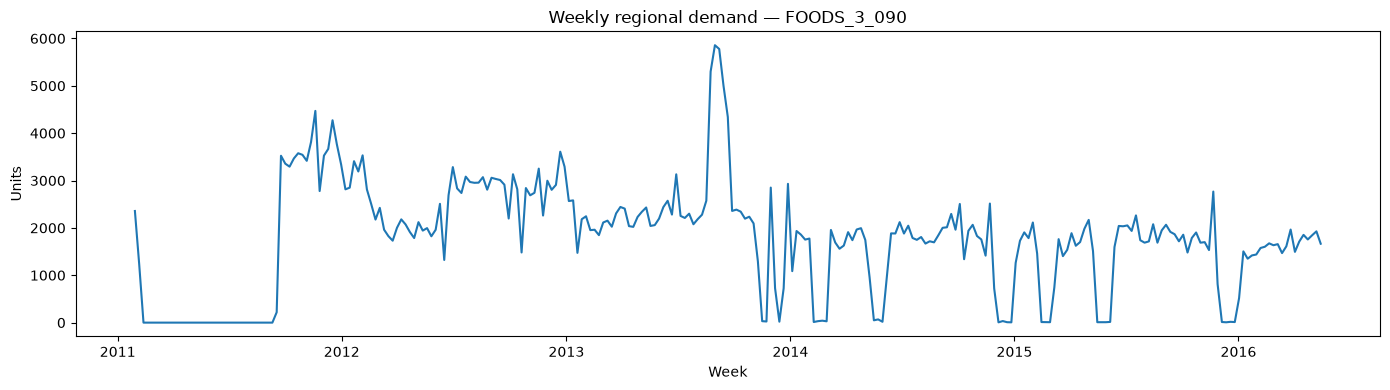

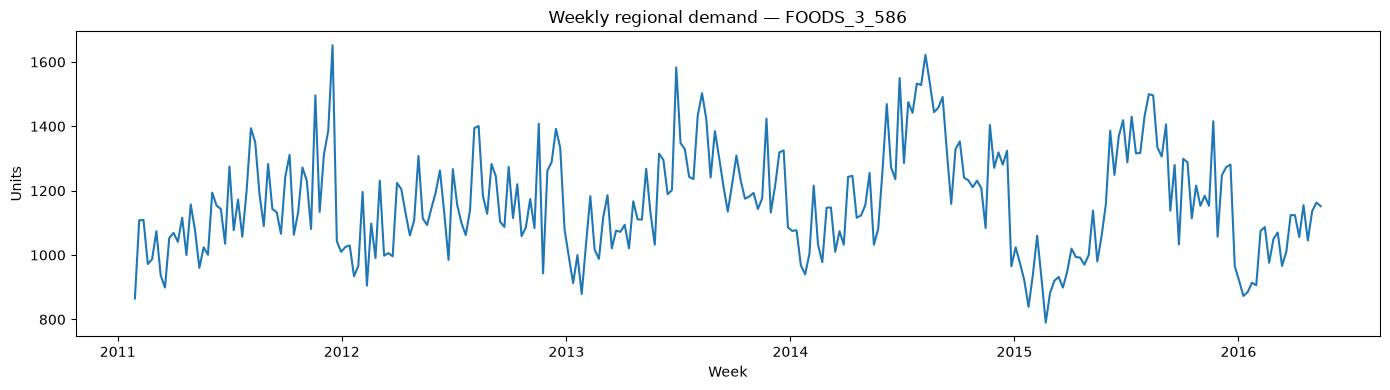

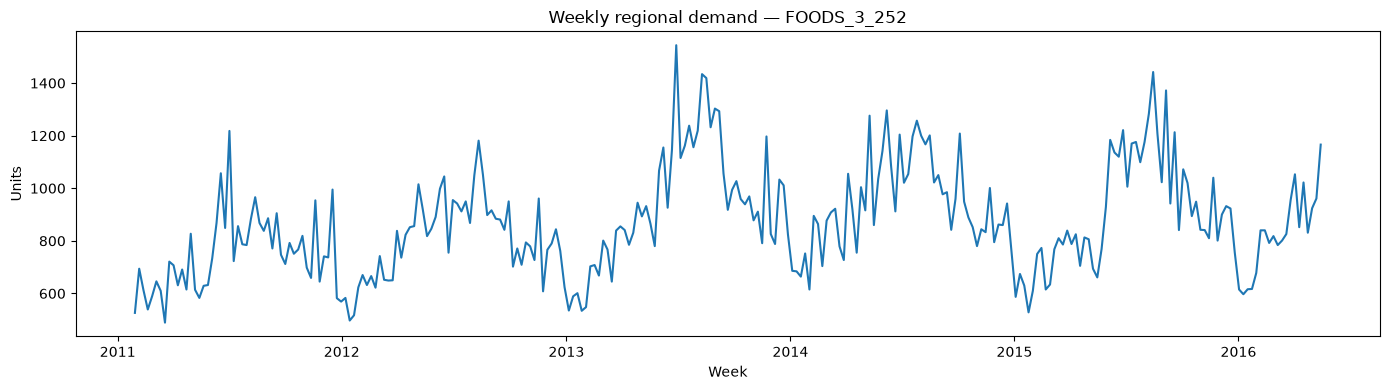

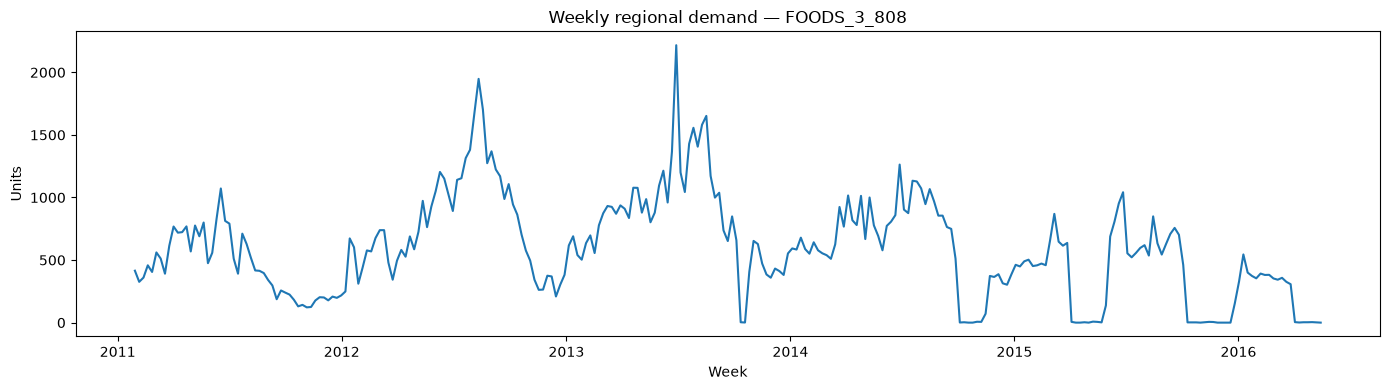

In [20]:
# Plot a handful of selected SKU demand histories.

example_skus = (
    sku_manifest
    .head(4)
    ["sku_id"]
    .tolist()
)

for sku in example_skus:

    plot_df = panel.loc[
        panel["sku_id"].eq(sku)
    ]

    plt.figure(figsize=(14, 4))

    plt.plot(
        plot_df["week_start"],
        plot_df["demand"],
    )

    plt.title(
        f"Weekly regional demand — {sku}"
    )

    plt.xlabel("Week")
    plt.ylabel("Units")

    plt.tight_layout()
    plt.show()

In [21]:
price_summary = (
    panel
    .groupby("sku_id")
    .agg(
        mean_price=("sell_price", "mean"),
        min_price=("sell_price_min", "min"),
        max_price=("sell_price_max", "max"),
        mean_price_coverage=("price_coverage", "mean"),
        missing_price_fraction=(
            "price_available",
            lambda x: (~x).mean(),
        ),
    )
    .sort_values(
        "mean_price",
        ascending=False,
    )
)

price_summary

,mean_price,min_price,max_price,mean_price_coverage,missing_price_fraction
sku_id,,,,,
FOODS_3_120,4.977056,3.33,4.98,0.811372,0.187726
FOODS_3_202,4.295361,3.00,4.68,1.000000,0.000000
FOODS_2_197,3.232383,2.98,3.43,1.000000,0.000000
FOODS_3_587,2.545794,1.98,2.68,1.000000,0.000000
FOODS_3_607,2.249033,1.98,2.48,0.812274,0.187726
FOODS_3_694,1.604639,1.48,1.68,1.000000,0.000000
FOODS_3_555,1.594350,1.48,1.68,1.000000,0.000000
FOODS_3_080,1.594350,1.48,1.68,1.000000,0.000000
FOODS_3_586,1.594350,1.48,1.68,1.000000,0.000000


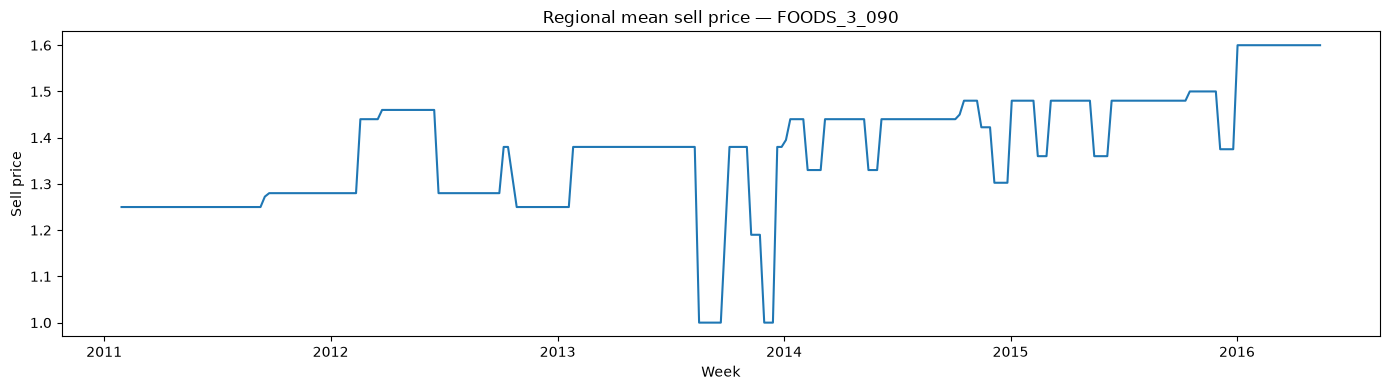

In [22]:
example_sku = sku_manifest.iloc[0]["sku_id"]

plot_df = panel.loc[
    panel["sku_id"].eq(example_sku)
]

plt.figure(figsize=(14, 4))

plt.plot(
    plot_df["week_start"],
    plot_df["sell_price"],
)

plt.title(
    f"Regional mean sell price — {example_sku}"
)

plt.xlabel("Week")
plt.ylabel("Sell price")

plt.tight_layout()
plt.show()

In [23]:
panel[
    [
        "week_start",
        "snap_days",
        "event_days",
        "cultural_event_days",
        "national_event_days",
        "religious_event_days",
        "sporting_event_days",
    ]
].drop_duplicates().head(20)

,week_start,snap_days,event_days,cultural_event_days,national_event_days,religious_event_days,sporting_event_days
0,2011-01-29,4,0,0,0,0,0
20,2011-02-05,6,1,0,0,0,1
40,2011-02-12,0,1,1,0,0,0
60,2011-02-19,0,1,0,1,0,0
80,2011-02-26,4,0,0,0,0,0
100,2011-03-05,6,1,0,0,1,0
120,2011-03-12,0,2,1,0,1,0
140,2011-03-19,0,1,0,0,1,0
160,2011-03-26,1,0,0,0,0,0
180,2011-04-02,7,0,0,0,0,0


In [24]:
event_demand = (
    panel
    .assign(
        has_event_week=lambda x:
            x["event_days"] > 0
    )
    .groupby("has_event_week")
    ["demand"]
    .agg(
        ["mean", "median", "std", "count"]
    )
)

event_demand

,mean,median,std,count
has_event_week,,,,
False,601.186552,491.0,509.614450,2900
True,575.938258,474.0,494.824835,2640


In [25]:
# ============================================================
# FINAL STAGE-1 DATA CONTRACT VALIDATION
# ============================================================

from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd()

# Handle notebook launched from notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


PANEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "m5_weekly_panel.parquet"
)

SKU_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "selected_skus.csv"
)


panel = pd.read_parquet(PANEL_PATH)
selected_skus = pd.read_csv(SKU_PATH)


# ------------------------------------------------------------
# 1. Basic shape
# ------------------------------------------------------------

n_rows = len(panel)
n_skus = panel["sku_id"].nunique()
n_weeks = panel["wm_yr_wk"].nunique()

print("Rows: ", n_rows)
print("SKUs: ", n_skus)
print("Weeks:", n_weeks)

print(
    "Date range:",
    panel["week_start"].min(),
    "->",
    panel["week_end"].max(),
)


# ------------------------------------------------------------
# 2. Primary-key contract
# ------------------------------------------------------------

assert not panel.duplicated(
    ["week_start", "sku_id"]
).any(), "Duplicate (week_start, sku_id) rows found"


# ------------------------------------------------------------
# 3. SKU contract
# ------------------------------------------------------------

assert n_skus <= 20, (
    f"Expected <=20 SKUs, found {n_skus}"
)

assert n_skus == selected_skus["sku_id"].nunique(), (
    "SKU manifest and panel disagree"
)


# ------------------------------------------------------------
# 4. Demand contract
# ------------------------------------------------------------

assert panel["demand"].notna().all(), (
    "Missing demand values found"
)

assert panel["demand"].ge(0).all(), (
    "Negative demand values found"
)


# ------------------------------------------------------------
# 5. Weekly-frequency contract
# ------------------------------------------------------------

assert panel["days_in_week"].eq(7).all(), (
    "Incomplete weeks found"
)


# ------------------------------------------------------------
# 6. Balanced panel contract
# ------------------------------------------------------------

expected_rows = n_skus * n_weeks

assert len(panel) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"found {len(panel)}"
)

weeks_per_sku = (
    panel
    .groupby("sku_id")
    ["wm_yr_wk"]
    .nunique()
)

assert weeks_per_sku.eq(n_weeks).all(), (
    "Some SKUs do not contain all weeks"
)


# ------------------------------------------------------------
# 7. Calendar contract
# ------------------------------------------------------------

required_calendar_cols = [
    "week_start",
    "week_end",
    "wm_yr_wk",
    "year",
    "month",
    "week_of_year",
    "snap_days",
    "event_days",
]

assert panel[
    required_calendar_cols
].notna().all().all(), (
    "Missing required calendar fields"
)


# ------------------------------------------------------------
# 8. Price sanity
# ------------------------------------------------------------

assert panel["price_coverage"].between(
    0,
    1,
).all(), "Invalid price coverage"

observed_price = panel["sell_price"].notna()

assert panel.loc[
    observed_price,
    "sell_price",
].gt(0).all(), "Non-positive observed prices found"


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print()
print("=" * 70)
print("STAGE 1 DATA CONTRACT PASSED")
print("=" * 70)

print(
    f"{n_skus} SKUs × "
    f"{n_weeks} weeks = "
    f"{n_rows:,} rows"
)

print(
    "Missing-price rows:",
    f"{panel['sell_price'].isna().mean():.2%}",
)

print(
    "Zero-demand rows:",
    f"{panel['demand'].eq(0).mean():.2%}",
)

print("=" * 70)

Rows:  5540
SKUs:  20
Weeks: 277
Date range: 2011-01-29 00:00:00 -> 2016-05-20 00:00:00

STAGE 1 DATA CONTRACT PASSED
20 SKUs × 277 weeks = 5,540 rows
Missing-price rows: 1.90%
Zero-demand rows: 5.56%


In [26]:
panel.head(10)

,week_start,week_end,wm_yr_wk,sku_id,cat_id,dept_id,demand,year,quarter,month,week_of_year,snap_days,event_days,cultural_event_days,national_event_days,religious_event_days,sporting_event_days,sell_price,sell_price_min,sell_price_max,sell_price_std,price_store_count,price_coverage,price_available,days_in_week
0,2011-01-29,2011-02-04,11101,FOODS_2_197,FOODS,FOODS_2,702,2011,1,1,4,4,0,0,0,0,0,2.98,2.98,2.98,0.0,4,1.0,True,7
1,2011-01-29,2011-02-04,11101,FOODS_3_080,FOODS,FOODS_3,496,2011,1,1,4,4,0,0,0,0,0,1.48,1.48,1.48,0.0,4,1.0,True,7
2,2011-01-29,2011-02-04,11101,FOODS_3_090,FOODS,FOODS_3,2357,2011,1,1,4,4,0,0,0,0,0,1.25,1.25,1.25,0.0,4,1.0,True,7
3,2011-01-29,2011-02-04,11101,FOODS_3_120,FOODS,FOODS_3,0,2011,1,1,4,4,0,0,0,0,0,NaN,NaN,NaN,NaN,0,0.0,False,7
4,2011-01-29,2011-02-04,11101,FOODS_3_202,FOODS,FOODS_3,207,2011,1,1,4,4,0,0,0,0,0,4.38,4.38,4.38,0.0,4,1.0,True,7
5,2011-01-29,2011-02-04,11101,FOODS_3_252,FOODS,FOODS_3,526,2011,1,1,4,4,0,0,0,0,0,1.48,1.48,1.48,0.0,4,1.0,True,7
6,2011-01-29,2011-02-04,11101,FOODS_3_281,FOODS,FOODS_3,0,2011,1,1,4,4,0,0,0,0,0,NaN,NaN,NaN,NaN,0,0.0,False,7
7,2011-01-29,2011-02-04,11101,FOODS_3_318,FOODS,FOODS_3,3840,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.0,4,1.0,True,7
8,2011-01-29,2011-02-04,11101,FOODS_3_319,FOODS,FOODS_3,91,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.0,2,0.5,True,7
9,2011-01-29,2011-02-04,11101,FOODS_3_541,FOODS,FOODS_3,437,2011,1,1,4,4,0,0,0,0,0,1.00,1.00,1.00,0.0,4,1.0,True,7


In [27]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 5540 entries, 0 to 5539
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   week_start            5540 non-null   datetime64[us]
 1   week_end              5540 non-null   datetime64[us]
 2   wm_yr_wk              5540 non-null   int64         
 3   sku_id                5540 non-null   str           
 4   cat_id                5540 non-null   str           
 5   dept_id               5540 non-null   str           
 6   demand                5540 non-null   int64         
 7   year                  5540 non-null   int16         
 8   quarter               5540 non-null   int8          
 9   month                 5540 non-null   int8          
 10  week_of_year          5540 non-null   int16         
 11  snap_days             5540 non-null   int8          
 12  event_days            5540 non-null   int8          
 13  cultural_event_days   5540 no

In [28]:
sku_summary = (
    panel
    .groupby("sku_id")
    .agg(
        weeks=("wm_yr_wk", "nunique"),
        total_demand=("demand", "sum"),
        mean_weekly_demand=("demand", "mean"),
        std_weekly_demand=("demand", "std"),
        zero_week_pct=(
            "demand",
            lambda x: 100 * x.eq(0).mean(),
        ),
        mean_price=("sell_price", "mean"),
        price_missing_pct=(
            "sell_price",
            lambda x: 100 * x.isna().mean(),
        ),
    )
    .sort_values(
        "total_demand",
        ascending=False,
    )
)

sku_summary.round(2)

,weeks,total_demand,mean_weekly_demand,std_weekly_demand,zero_week_pct,mean_price,price_missing_pct
sku_id,,,,,,,
FOODS_3_090,277,492750,1778.88,1160.42,11.19,1.37,0.00
FOODS_3_586,277,322186,1163.13,164.32,0.00,1.59,0.00
FOODS_3_252,277,240745,869.12,200.84,0.00,1.52,0.00
FOODS_3_120,277,179749,648.91,483.82,22.02,4.98,18.77
FOODS_3_587,277,168258,607.43,374.88,0.00,2.55,0.00
FOODS_3_808,277,165787,598.51,397.87,3.97,1.00,0.00
FOODS_3_635,277,158206,571.14,360.23,4.69,1.00,0.00
FOODS_3_541,277,156597,565.33,351.21,6.14,1.00,0.00
FOODS_3_714,277,147982,534.23,115.84,0.00,1.52,0.00
